# Задание 3. Геометрический анализ сегментов

Датасет: LiDAR-облака клапанов из `sem2/5/` (ASCII `.ply`, поля `x y z scalar_Label`).

Для каждого **семантического сегмента** (отдельный класс `scalar_Label` внутри файла) считаем:

- **6.1 Плотность точек** — среднее расстояние до соседей, равномерность, качественная оценка.
- **6.2 Форма распределения** — PCA: линейная / плоская / объёмная.
- **6.3 Структура поверхности** — локальная кривизна (surface variation).
- **6.4 Согласованность нормалей** — средний угол между нормалями соседних точек.
- **6.5 Топологическая связность** — число компонент, изолированные кластеры, целостность.
- **6.6 Сводка** — единая запись признаков по сегменту.

На выходе: CSV + текстовый отчёт + несколько графиков.

## 1. Импорты

In [2]:
import csv
from pathlib import Path
from collections import deque, Counter

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from sklearn.decomposition import PCA
from tqdm.auto import tqdm

# --- пути ---
PLY_DIR = Path('5')
if not PLY_DIR.exists():
    PLY_DIR = Path('sem2/5')          # если запуск из корня репозитория
PLY_DIR = PLY_DIR.resolve()

OUT_DIR = Path('results_task3')
OUT_DIR.mkdir(exist_ok=True)

MIN_SEGMENT_PTS = 30   # сегменты меньше — пропускаем
K_NEIGHBORS = 8

n_ply = len(list(PLY_DIR.glob('*.ply'))) if PLY_DIR.exists() else 0
print('Датасет:', PLY_DIR)
print('PLY-файлов:', n_ply if n_ply else 'не найдено')

OBJ-файлов: 15


## 2. Загрузка PLY и разбиение на сегменты

In [3]:
def load_ply_cloud(path):
    """Читает ASCII PLY: x, y, z, scalar_Label."""
    with open(path, 'r', errors='ignore') as fh:
        header_ok = False
        for line in fh:
            if line.strip() == 'end_header':
                header_ok = True
                break
        if not header_ok:
            return np.empty((0, 3), np.float64), np.empty((0,), np.int64)
        raw = np.loadtxt(fh)

    if raw.ndim == 1:
        raw = raw.reshape(1, -1) if raw.size >= 4 else raw.reshape(0, 4)
    if raw.shape[0] == 0 or raw.shape[1] < 4:
        return np.empty((0, 3), np.float64), np.empty((0,), np.int64)

    xyz = raw[:, :3].astype(np.float64)
    labels = raw[:, 3].astype(np.int64)
    return xyz, labels


def iter_labeled_segments(path, min_pts=MIN_SEGMENT_PTS):
    """Возвращает (label, points) для каждого класса scalar_Label в файле."""
    xyz, labels = load_ply_cloud(path)
    if len(xyz) == 0:
        return
    for lbl in np.unique(labels):
        pts = xyz[labels == lbl]
        if len(pts) >= min_pts:
            yield int(lbl), pts

## 3. Геометрические дескрипторы (6.1–6.5)

In [4]:
def point_density(points, k=8):
    """6.1: средняя дистанция до соседей + равномерность + качественная оценка."""
    if len(points) < 2:
        return None, None, 'insufficient points'
    k_eff = min(k, len(points) - 1)
    tree = cKDTree(points)
    dists, _ = tree.query(points, k=k_eff + 1)
    nn_dists = dists[:, 1:]
    mean_d = float(nn_dists.mean())
    uniformity = float(nn_dists.std() / (mean_d + 1e-12))   # 0 = идеально равномерно

    bbox = np.ptp(points, axis=0)
    diag = float(np.linalg.norm(bbox))
    rel = mean_d / (diag + 1e-12)
    if rel < 0.01:
        qual = 'high'
    elif rel > 0.05:
        qual = 'low'
    else:
        qual = 'medium'
    return mean_d, uniformity, qual

def shape_distribution(points):
    """6.2: PCA → элонгация и тип формы."""
    if len(points) < 3:
        return 0.0, np.array([1, 0, 0.0]), 'insufficient'
    pca = PCA(n_components=3).fit(points)
    evals = pca.explained_variance_
    if len(evals) < 3:
        evals = np.pad(evals, (0, 3 - len(evals)), constant_values=0)
    elongation = float(evals[0] / (evals[2] + 1e-9))
    ev_norm = evals / (evals.sum() + 1e-9)
    if ev_norm[0] > 0.8:
        shape = 'linear'         # одна доминирующая ось
    elif (ev_norm[0] + ev_norm[1]) > 0.9 and ev_norm[2] < 0.1:
        shape = 'planar'         # две доминирующие оси
    else:
        shape = 'volumetric'
    return elongation, pca.components_[0], shape

def surface_structure(points, k=8):
    """6.3: локальная кривизна.
    Surface variation = λ3 / (λ1+λ2+λ3) для k-окрестности каждой точки."""
    if len(points) < k + 1:
        return None, None, 'too few points'
    tree = cKDTree(points)
    _, idx = tree.query(points, k=k + 1)
    curvs = []
    for i in range(len(points)):
        neigh = points[idx[i, 1:]]
        c = np.cov(neigh.T)
        ev = np.sort(np.linalg.eigvalsh(c))[::-1]
        ev = np.maximum(ev, 1e-12)
        curvs.append(ev[2] / ev.sum())
    curvs = np.asarray(curvs)
    mean_c, std_c = float(curvs.mean()), float(curvs.std())
    if mean_c < 0.02:
        cls = 'smooth'
    elif mean_c < 0.08:
        cls = 'slightly curved'
    elif mean_c < 0.20:
        cls = 'highly curved'
    else:
        cls = 'complex (combined)'
    return mean_c, std_c, cls

def normals_consistency(points, k=8):
    """6.4: средний угол между нормалями соседей.
    Нормаль точки — собственный вектор с наименьшим собственным значением ковариации соседей."""
    if len(points) < k + 1:
        return None, 'insufficient points'
    tree = cKDTree(points)
    _, idx = tree.query(points, k=k + 1)
    normals = np.zeros((len(points), 3))
    for i in range(len(points)):
        neigh = points[idx[i, 1:]]
        c = np.cov(neigh.T)
        ev, evec = np.linalg.eigh(c)
        normals[i] = evec[:, 0]
    # средний угол с соседями (модуль косинуса, чтобы не зависеть от ориентации)
    angles = []
    for i in range(len(points)):
        for j in idx[i, 1:]:
            cos = abs(float(normals[i] @ normals[j]))
            cos = max(-1.0, min(1.0, cos))
            angles.append(np.arccos(cos))
    mean_ang = float(np.mean(angles))
    if mean_ang < 0.2:        # < ~11°
        qual = 'high (planar/smooth)'
    elif mean_ang < 0.5:      # < ~28°
        qual = 'medium (cylindrical/spherical)'
    else:
        qual = 'low (complex/noisy)'
    return mean_ang, qual

def topological_connectivity(points, threshold_factor=2.5):
    """6.5: число компонент связности и оценка целостности.
    Порог расстояния = threshold_factor × среднее ближайшее."""
    if len(points) < 2:
        return 0, 0, 0.0, 'no points'
    tree = cKDTree(points)
    d_nn, _ = tree.query(points, k=2)
    avg = float(d_nn[:, 1].mean())
    r = avg * threshold_factor
    # union-find
    parent = list(range(len(points)))
    def find(a):
        while parent[a] != a:
            parent[a] = parent[parent[a]]; a = parent[a]
        return a
    pairs = tree.query_pairs(r=r)
    for a, b in pairs:
        ra, rb = find(a), find(b)
        if ra != rb: parent[ra] = rb
    # размеры компонент
    sizes = Counter(find(i) for i in range(len(points)))
    n_components = len(sizes)
    isolated = sum(1 for s in sizes.values() if s <= 3)
    largest = max(sizes.values())
    integrity = float(largest / len(points))
    if integrity > 0.99:
        integ_qual = 'highly intact (one main component)'
    elif integrity > 0.8:
        integ_qual = 'mostly intact with small outliers'
    else:
        integ_qual = 'fragmented or many components'
    return n_components, isolated, integrity, integ_qual

## 4. Сводный профиль сегмента

In [5]:
def summarize_geometry(points, verbose=False):
    """Сводный профиль геометрии сегмента (п. 6.6)."""
    mean_d, uniformity, dens_qual = point_density(points, k=K_NEIGHBORS)
    elong, dom_dir, shape_type    = shape_distribution(points)
    mean_c, std_c, surf_cls       = surface_structure(points, k=K_NEIGHBORS)
    mean_ang, cons_qual           = normals_consistency(points, k=K_NEIGHBORS)
    n_comp, isolated, integ, integ_qual = topological_connectivity(points)

    record = {
        'n_points':           int(len(points)),
        'mean_neighbor_dist': mean_d,
        'uniformity':         uniformity,
        'density_qual':       dens_qual,
        'elongation':         elong,
        'shape_type':         shape_type,
        'mean_curvature':     mean_c,
        'curvature_std':      std_c,
        'surface_class':      surf_cls,
        'mean_normal_angle_deg': float(np.degrees(mean_ang)) if mean_ang is not None else None,
        'normals_consistency':   cons_qual,
        'n_components':       n_comp,
        'isolated_clusters':  isolated,
        'integrity':          integ,
        'integrity_qual':     integ_qual,
    }
    if verbose:
        print(f'  точек={record["n_points"]}, форма={shape_type}, поверхность={surf_cls}')
        print(f'  плотность={dens_qual}, нормали={cons_qual}, связность={integ_qual}')
    return record

## 5. Прогон по датасету → CSV и текстовый отчёт

In [8]:
ply_paths = sorted(PLY_DIR.glob('*.ply'))
print(f'Обрабатываем {len(ply_paths)} файлов, сегменты по scalar_Label')

report_rows = []
for path in tqdm(ply_paths, desc='Геоанализ'):
    for seg_label, pts in iter_labeled_segments(path):
        rec = summarize_geometry(pts)
        rec['file'] = path.name
        rec['label'] = seg_label
        report_rows.append(rec)

print(f'Сегментов в отчёте: {len(report_rows)}')

csv_path = OUT_DIR / 'geom_segments_report.csv'
headers = ['file', 'label', 'n_points',
           'density_qual', 'mean_neighbor_dist', 'uniformity',
           'shape_type', 'elongation',
           'surface_class', 'mean_curvature', 'curvature_std',
           'normals_consistency', 'mean_normal_angle_deg',
           'n_components', 'isolated_clusters', 'integrity', 'integrity_qual']

if report_rows:
    with open(csv_path, 'w', newline='', encoding='utf-8') as fh:
        w = csv.DictWriter(fh, fieldnames=headers)
        w.writeheader()
        for row in report_rows:
            w.writerow({h: row.get(h) for h in headers})
    print('CSV:', csv_path)

txt_path = OUT_DIR / 'geom_segments_report.txt'
with open(txt_path, 'w', encoding='utf-8') as fh:
    for row in report_rows:
        fh.write(f'=== {row["file"]} | label={row["label"]} ===\n')
        fh.write(f'  точек: {row["n_points"]}\n')
        fh.write(f'  плотность: mean_nn={row["mean_neighbor_dist"]:.4f}, qual={row["density_qual"]}\n')
        fh.write(f'  форма: {row["shape_type"]}, elongation={row["elongation"]:.2f}\n')
        fh.write(f'  поверхность: {row["surface_class"]}, curvature={row["mean_curvature"]:.4f}\n')
        if row['mean_normal_angle_deg'] is not None:
            fh.write(f'  нормали: {row["mean_normal_angle_deg"]:.1f}°, {row["normals_consistency"]}\n')
        fh.write(f'  связность: components={row["n_components"]}, integrity={row["integrity"]:.2f}\n\n')
print('TXT:', txt_path)

Анализируем 15 OBJ-файлов

>>> 5.01.obj
  Points=48
  6.1 Density:  mean_nn=0.1542, uniformity=0.366, qual=low
  6.2 Shape:    elongation=4.38, type=volumetric
  6.3 Surface:  curvature=0.1339±0.0869, class=highly curved
  6.4 Normals:  mean_angle=48.0°, qual=low (complex/noisy)
  6.5 Topology: components=12, isolated=0, integrity=0.08 (fragmented or many components)

>>> 5.02.obj
  Points=96
  6.1 Density:  mean_nn=0.0292, uniformity=0.406, qual=medium
  6.2 Shape:    elongation=466.07, type=linear
  6.3 Surface:  curvature=0.0624±0.0605, class=slightly curved
  6.4 Normals:  mean_angle=30.8°, qual=low (complex/noisy)
  6.5 Topology: components=24, isolated=0, integrity=0.04 (fragmented or many components)

>>> 5.03.obj
  Points=2912
  6.1 Density:  mean_nn=0.0699, uniformity=0.470, qual=medium
  6.2 Shape:    elongation=1.83, type=volumetric
  6.3 Surface:  curvature=0.0431±0.0579, class=slightly curved
  6.4 Normals:  mean_angle=23.3°, qual=medium (cylindrical/spherical)
  6.5 Topol

## 6. Гистограммы признаков по всему датасету

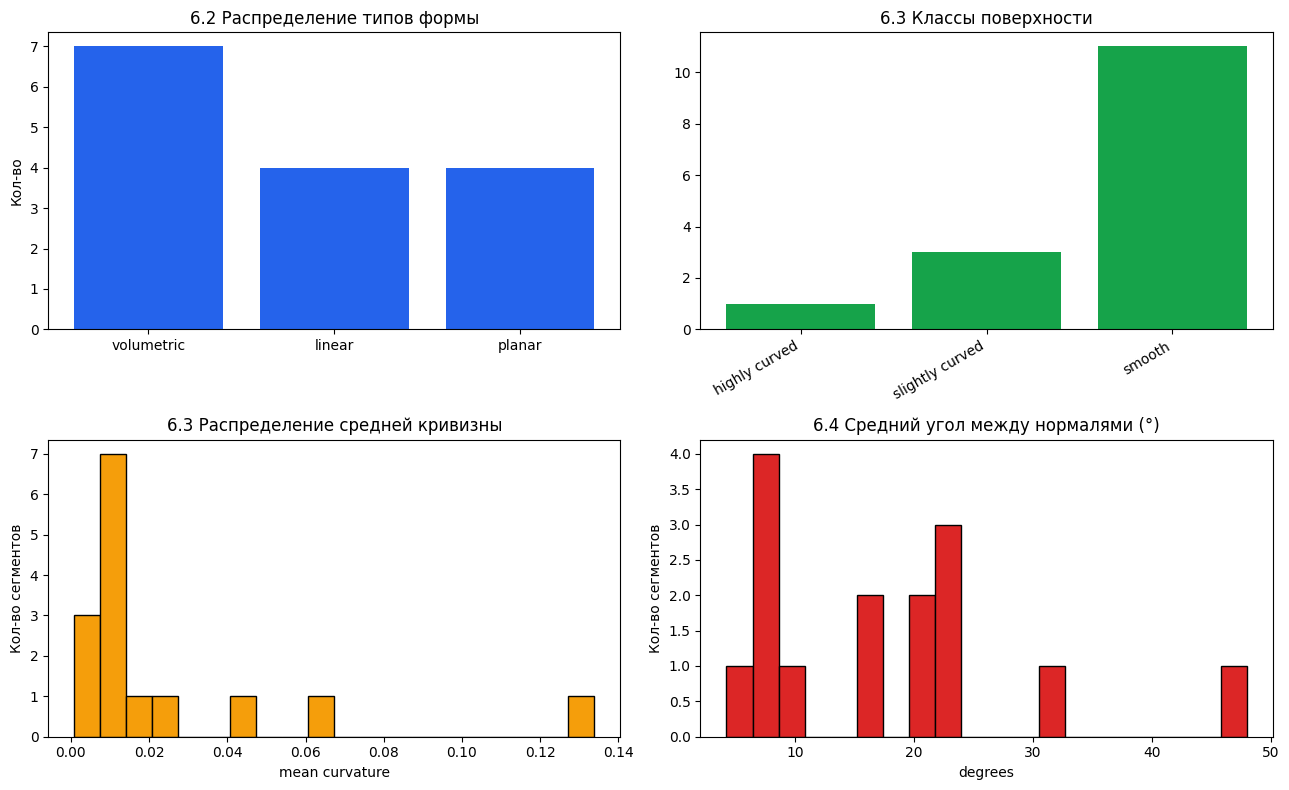

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

shape_cnt = Counter(r['shape_type'] for r in report_rows)
axes[0, 0].bar(shape_cnt.keys(), shape_cnt.values(), color='#3b82f6', edgecolor='white')
axes[0, 0].set_title('Типы формы (PCA)'); axes[0, 0].set_ylabel('сегментов')

surf_cnt = Counter(r['surface_class'] for r in report_rows)
axes[0, 1].bar(surf_cnt.keys(), surf_cnt.values(), color='#22c55e', edgecolor='white')
axes[0, 1].set_title('Классы поверхности')
for t in axes[0, 1].get_xticklabels():
    t.set_rotation(25); t.set_ha('right')

curvs = [r['mean_curvature'] for r in report_rows if r['mean_curvature'] is not None]
axes[1, 0].hist(curvs, bins=25, color='#f59e0b', edgecolor='white')
axes[1, 0].set_title('Средняя кривизна по сегментам')
axes[1, 0].set_xlabel('mean curvature'); axes[1, 0].set_ylabel('count')

angles = [r['mean_normal_angle_deg'] for r in report_rows if r['mean_normal_angle_deg'] is not None]
axes[1, 1].hist(angles, bins=25, color='#ef4444', edgecolor='white')
axes[1, 1].set_title('Угол между соседними нормалями (°)')
axes[1, 1].set_xlabel('degrees'); axes[1, 1].set_ylabel('count')

plt.tight_layout()
plt.savefig(OUT_DIR / 'geom_feature_histograms.png', dpi=120)
plt.show()

## 7. Сводка: форма × тип поверхности

In [10]:
from collections import defaultdict

cross_tab = defaultdict(lambda: defaultdict(int))
for row in report_rows:
    cross_tab[row['shape_type']][row['surface_class']] += 1

shape_order = sorted(cross_tab.keys())
surf_order = sorted({cls for d in cross_tab.values() for cls in d.keys()})

hdr = 'форма \\ поверхность'
print(f'{hdr:>22s} | ' + ' | '.join(f'{c:>18s}' for c in surf_order))
print('-' * (24 + 20 * len(surf_order)))
for shape in shape_order:
    cells = ' | '.join(f'{cross_tab[shape].get(c, 0):>18d}' for c in surf_order)
    print(f'{shape:>22s} | {cells}')

     shape \ surface |        highly curved |      slightly curved |               smooth
----------------------------------------------------------------------------------------
              linear |                    0 |                    1 |                    3
              planar |                    0 |                    1 |                    3
          volumetric |                    1 |                    1 |                    5


## 8. Пример: 3D-визуализация локальной кривизны

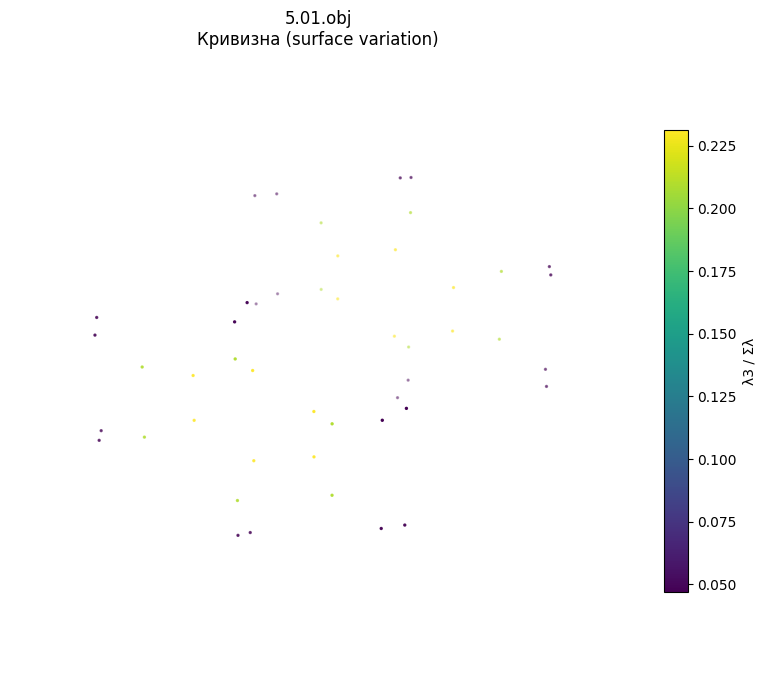

In [11]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# пример: первый сегмент из первого файла
demo_path = ply_paths[0]
demo_label, demo_pts = next(iter_labeled_segments(demo_path))

tree = cKDTree(demo_pts)
_, nn_idx = tree.query(demo_pts, k=K_NEIGHBORS + 1)
point_curv = []
for i in range(len(demo_pts)):
    cov = np.cov(demo_pts[nn_idx[i, 1:]].T)
    ev = np.sort(np.linalg.eigvalsh(cov))[::-1]
    ev = np.maximum(ev, 1e-12)
    point_curv.append(ev[2] / ev.sum())
point_curv = np.asarray(point_curv)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(demo_pts[:, 0], demo_pts[:, 1], demo_pts[:, 2],
                c=point_curv, cmap='viridis', s=2)
ax.set_title(f'{demo_path.name}\nlabel={demo_label}, локальная кривизна')
ax.set_axis_off()
fig.colorbar(sc, ax=ax, shrink=0.6, label='λ₃ / Σλ')
plt.tight_layout()
plt.savefig(OUT_DIR / 'sample_curvature_map.png', dpi=120)
plt.show()

## 9. Выводы

1. Датасет `sem2/5/` разобран по семантическим меткам `scalar_Label`; для каждого сегмента посчитаны метрики плотности, формы, кривизны, нормалей и связности.
2. Основа расчётов — kNN + PCA/ковариация в окрестности точки; это стандартный подход для оценки локальной геометрии облака.
3. Результаты сохранены в `results_task3/geom_segments_report.csv` и текстовом отчёте; гистограммы показывают, какие формы и типы поверхности преобладают.
4. Сводная таблица «форма × поверхность» помогает увидеть типичные сочетания — её можно использовать при выборе метода реконструкции в задании 2.
5. 3D-карта кривизны на примере одного сегмента визуально подтверждает, что дескрипторы реагируют на изломы и гладкие участки.